# NumPy Random Distributions: Tasks 1–5

This notebook uses one reproducible NumPy random-number generator, reusable helper functions, parameter validation, simple tests, and optional visualizations. Run the cells from top to bottom. Change `SEED` (or set it to `None`) when you need a different simulation.

In [1]:
from __future__ import annotations

from typing import Any
import numpy as np

# Plotting is optional; calculations and tests still run if Matplotlib is unavailable.
try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False
    plt = None

# A fixed seed makes the notebook results reproducible. Use None for a new result each run.
SEED = 20260808
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=3, suppress=True)

## Reusable functions and validation

Validation catches common simulation mistakes early: counts must be positive integers, interval lower bounds must be smaller than upper bounds, probabilities must be in `[0, 1]`, and distribution parameters such as standard deviation and Poisson rate must be positive.

In [2]:
def _positive_int(value: int, name: str) -> int:
    """Return a validated positive integer."""
    if isinstance(value, bool) or not isinstance(value, (int, np.integer)) or value <= 0:
        raise ValueError(f'{name} must be a positive integer; got {value!r}.')
    return int(value)


def _interval(low: float, high: float, name: str = 'range') -> tuple[float, float]:
    """Validate and return an increasing numeric interval."""
    if not np.isfinite(low) or not np.isfinite(high) or low >= high:
        raise ValueError(f'{name} requires finite values with low < high; got ({low}, {high}).')
    return float(low), float(high)


def _probability(p: float) -> float:
    """Validate a probability in the inclusive interval [0, 1]."""
    if not np.isfinite(p) or not 0 <= p <= 1:
        raise ValueError(f'p must be between 0 and 1; got {p}.')
    return float(p)


def summary(values: np.ndarray) -> dict[str, float]:
    """Calculate basic statistics once for any non-empty numeric array."""
    values = np.asarray(values)
    if values.size == 0:
        raise ValueError('values must not be empty.')
    return {'mean': float(values.mean()), 'min': float(values.min()), 'max': float(values.max())}


def random_number_sets(generator: np.random.Generator, count: int = 10) -> dict[str, np.ndarray]:
    """Generate integers, floats, a 5×5 matrix, and decimals from 5 to 10."""
    count = _positive_int(count, 'count')
    return {
        'integers': generator.integers(1, 101, size=count),
        'floats': generator.random(count),
        'matrix': generator.random((5, 5)),
        'decimals_5_to_10': generator.uniform(5, 10, size=count),
    }


def uniform_sample(generator: np.random.Generator, low: float, high: float, size: int) -> np.ndarray:
    """Generate values with equal probability across [low, high)."""
    low, high = _interval(low, high, 'uniform range')
    return generator.uniform(low, high, size=_positive_int(size, 'size'))


def normal_sample(generator: np.random.Generator, mean: float, std_dev: float, size: int) -> np.ndarray:
    """Generate bell-shaped values around mean with positive standard deviation."""
    if not np.isfinite(mean) or not np.isfinite(std_dev) or std_dev <= 0:
        raise ValueError('mean must be finite and std_dev must be a positive finite number.')
    return generator.normal(mean, std_dev, size=_positive_int(size, 'size'))


def binomial_sample(generator: np.random.Generator, trials: int, p: float, size: int) -> np.ndarray:
    """Simulate successes from repeated independent yes/no trials."""
    return generator.binomial(_positive_int(trials, 'trials'), _probability(p), size=_positive_int(size, 'size'))


def poisson_sample(generator: np.random.Generator, rate: float, size: int) -> np.ndarray:
    """Simulate event counts in equal intervals for a positive average rate."""
    if not np.isfinite(rate) or rate <= 0:
        raise ValueError('rate must be a positive finite number.')
    return generator.poisson(rate, size=_positive_int(size, 'size'))


## Task 1 – Different random numbers

Integers are sampled from 1–100, floating-point values from 0–1, the matrix is 5 × 5, and decimal values are in the interval 5–10.

In [3]:
task_1 = random_number_sets(rng, count=10)

print('10 random integers:')
print(task_1['integers'])
print('\n10 random floating-point values:')
print(task_1['floats'])
print('\n5 × 5 random matrix:')
print(task_1['matrix'])
print('\nRandom decimal values between 5 and 10:')
print(task_1['decimals_5_to_10'])

10 random integers:
[98 25 16 74 32 63 47 71 58  6]

10 random floating-point values:
[0.748 0.514 0.534 0.652 0.9   0.628 0.639 0.438 0.756 0.73 ]

5 × 5 random matrix:
[[0.476 0.581 0.796 0.077 0.294]
 [0.096 0.713 0.176 0.347 0.043]
 [0.662 0.859 0.947 0.503 0.138]
 [0.769 0.617 0.858 0.21  0.002]
 [0.629 0.129 0.58  0.271 0.823]]

Random decimal values between 5 and 10:
[9.082 7.156 7.061 7.368 9.67  6.822 8.829 6.114 8.246 7.245]


## Task 2 – Uniform distribution

A uniform distribution gives every value within its range the same likelihood. Example: selecting a random temperature setting anywhere from 10 °C to 50 °C with no preference for a particular setting.

In [4]:
uniform_values = uniform_sample(rng, low=10, high=50, size=1_000)
uniform_stats = summary(uniform_values)

print('Uniform distribution (n=1000, range=[10, 50))')
for label, value in uniform_stats.items():
    print(f'{label.title():<7}: {value:.3f}')

Uniform distribution (n=1000, range=[10, 50))
Mean   : 30.257
Min    : 10.017
Max    : 49.886


## Task 3 – Normal distribution

A normal distribution is a symmetric bell shape: values close to the average are common and extreme values are rare. Example: adult heights or measurement error around a target value.

In [5]:
normal_values = normal_sample(rng, mean=50, std_dev=10, size=1_000)
normal_stats = {
    'mean': float(normal_values.mean()),
    'median': float(np.median(normal_values)),
    'standard deviation': float(normal_values.std()),  # Population SD for this simulated population.
}

print('Normal distribution (mean=50, standard deviation=10, n=1000)')
for label, value in normal_stats.items():
    print(f'{label.title():<20}: {value:.3f}')

Normal distribution (mean=50, standard deviation=10, n=1000)
Mean                : 50.486
Median              : 50.606
Standard Deviation  : 10.008


## Task 4 – Binomial distribution

A binomial distribution counts successes in a fixed number of independent yes/no trials. Here each student is one trial (`n=1`), with an 80% chance of passing. Example: counting defective versus non-defective products in a batch.

In [6]:
student_results = binomial_sample(rng, trials=1, p=0.8, size=1_000)
passed = int(student_results.sum())
failed = int(student_results.size - passed)
average_passing_result = float(student_results.mean())

print('Binomial distribution (1000 students, p=0.8)')
print(f'Students passed         : {passed}')
print(f'Students failed         : {failed}')
print(f'Average passing result  : {average_passing_result:.3f} ({average_passing_result:.1%})')

Binomial distribution (1000 students, p=0.8)
Students passed         : 800
Students failed         : 200
Average passing result  : 0.800 (80.0%)


## Task 5 – Poisson distribution

A Poisson distribution models how many independent events occur in a fixed interval when they occur at a steady average rate. Example: the number of customer arrivals at a store per hour.

In [7]:
hourly_arrivals = poisson_sample(rng, rate=8, size=500)
poisson_stats = summary(hourly_arrivals)

print('Poisson distribution (500 hours, average rate=8 arrivals/hour)')
for label, value in poisson_stats.items():
    print(f'{label.title():<7}: {value:.3f}')

Poisson distribution (500 hours, average rate=8 arrivals/hour)
Mean   : 8.010
Min    : 2.000
Max    : 17.000


## Simple comparison of distributions

| Distribution | What it describes | Simple example |
|---|---|---|
| Uniform | Any value in a range is equally likely. | Randomly choosing a time between 10:00 and 10:50. |
| Normal | Continuous values cluster around an average in a bell shape. | Test scores near the class average. |
| Binomial | Number of successes in a fixed number of yes/no trials. | Number of students who pass. |
| Poisson | Number of events in a fixed time/space interval. | Customer arrivals per hour. |
| Exponential | Waiting time until the next independent event. | Minutes until the next customer arrives. |

Poisson answers **how many events** happen in an interval; exponential answers **how long until the next event**. For a process with rate 8 arrivals/hour, waiting time can be simulated with `rng.exponential(scale=1 / 8, size=500)`, where the scale is measured in hours.

## Visualizations

Use a histogram to see the distribution's shape and a density-scaled histogram to compare distributions with different sample sizes. Use a box plot to quickly compare center, spread, and outliers. For continuous distributions, a KDE/density plot can provide a smooth shape estimate; treat it cautiously near boundaries such as the uniform range.

C:\Users\Aarya\AppData\Local\Temp\ipykernel_27148\1854183581.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes.flat[3].boxplot(list(samples.values()), labels=list(samples.keys()), patch_artist=True)


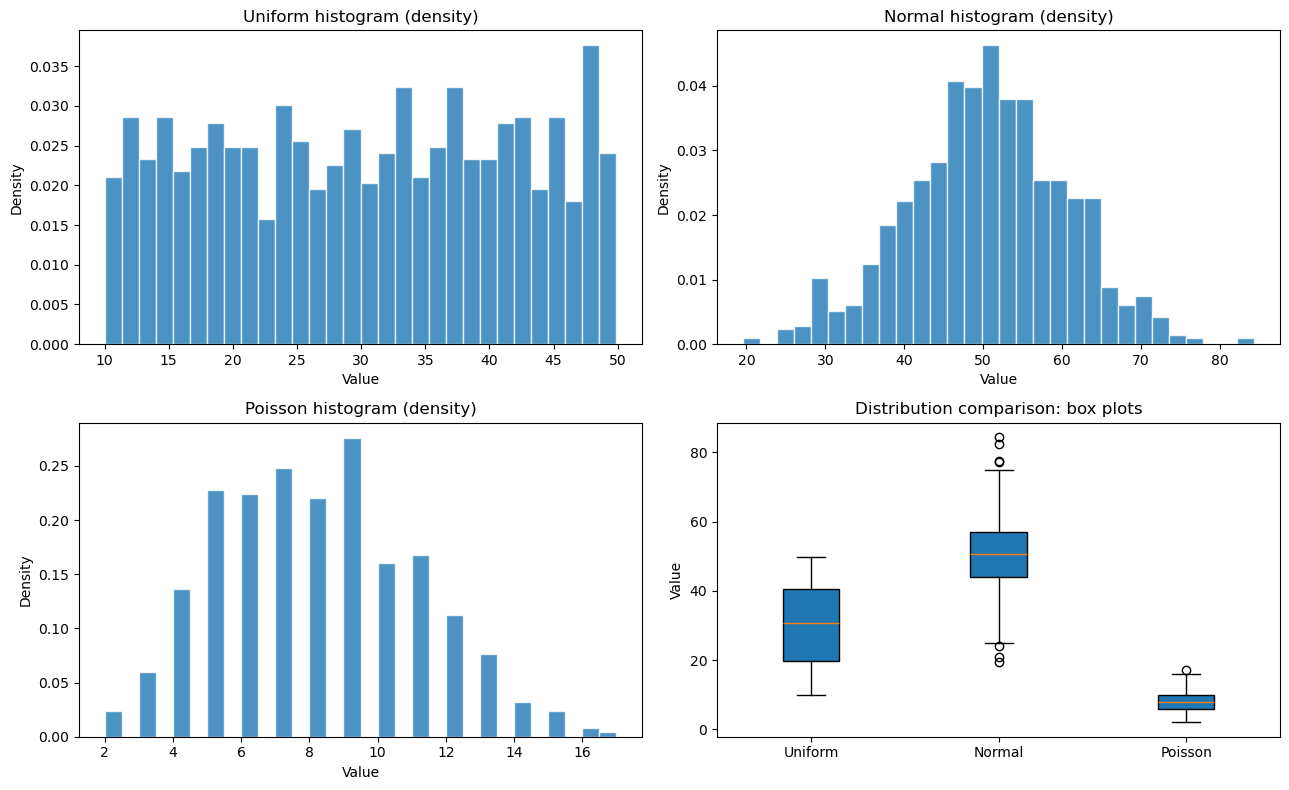

In [8]:
def plot_samples(samples: dict[str, np.ndarray]) -> None:
    """Draw histograms and a comparative box plot when Matplotlib is installed."""
    if not HAS_MATPLOTLIB:
        print('Matplotlib is not installed; install it to render the recommended charts.')
        return
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    for axis, (name, values) in zip(axes.flat[:3], samples.items()):
        axis.hist(values, bins=30, density=True, edgecolor='white', alpha=0.8)
        axis.set(title=f'{name} histogram (density)', xlabel='Value', ylabel='Density')
    axes.flat[3].boxplot(list(samples.values()), labels=list(samples.keys()), patch_artist=True)
    axes.flat[3].set(title='Distribution comparison: box plots', ylabel='Value')
    fig.tight_layout()


plot_samples({
    'Uniform': uniform_values,
    'Normal': normal_values,
    'Poisson': hourly_arrivals,
})
if HAS_MATPLOTLIB:
    plt.show()

## Unit tests for helper functions

These lightweight tests confirm valid shapes/ranges and ensure invalid parameters fail clearly. They use a separate seeded generator so they do not change the task results above.

In [9]:
def assert_raises(expected_exception: type[Exception], function: Any, *args: Any, **kwargs: Any) -> None:
    """Assert that a function raises the expected exception type."""
    try:
        function(*args, **kwargs)
    except expected_exception:
        return
    except Exception as error:
        raise AssertionError(f'Expected {expected_exception.__name__}, got {type(error).__name__}.') from error
    raise AssertionError(f'Expected {expected_exception.__name__} to be raised.')


def run_unit_tests() -> None:
    """Run basic tests without an external testing framework."""
    test_rng = np.random.default_rng(123)
    random_sets = random_number_sets(test_rng, 10)
    assert random_sets['integers'].shape == (10,)
    assert np.all((random_sets['integers'] >= 1) & (random_sets['integers'] <= 100))
    assert random_sets['matrix'].shape == (5, 5)
    assert np.all((random_sets['decimals_5_to_10'] >= 5) & (random_sets['decimals_5_to_10'] < 10))

    uniform = uniform_sample(test_rng, 10, 50, 100)
    assert uniform.shape == (100,) and np.all((uniform >= 10) & (uniform < 50))
    assert normal_sample(test_rng, 50, 10, 8).shape == (8,)
    binomial = binomial_sample(test_rng, 1, 0.8, 50)
    assert set(np.unique(binomial)).issubset({0, 1})
    assert np.all(poisson_sample(test_rng, 8, 50) >= 0)
    assert summary(np.array([1, 2, 3])) == {'mean': 2.0, 'min': 1.0, 'max': 3.0}

    assert_raises(ValueError, uniform_sample, test_rng, 50, 10, 10)
    assert_raises(ValueError, normal_sample, test_rng, 50, 0, 10)
    assert_raises(ValueError, binomial_sample, test_rng, 1, 1.1, 10)
    assert_raises(ValueError, poisson_sample, test_rng, 0, 10)
    assert_raises(ValueError, random_number_sets, test_rng, 0)
    print('All helper-function tests passed.')


run_unit_tests()

All helper-function tests passed.


## Performance and code-quality review

**For large datasets:** generate entire arrays in one NumPy call (never Python loops), keep arrays numeric rather than Python lists, calculate summaries with vectorized methods such as `.mean()` and `.max()`, and avoid retaining unneeded intermediate arrays. When data cannot fit in memory, generate and aggregate in chunks; use `float32` or smaller integer types only if the precision/range is suitable. Avoid plotting every point in very large samples—use bins, sampling, or aggregated plots.

**Review:** the notebook separates validation, generation, analysis, plotting, and tests; uses descriptive names and docstrings; and uses a local `Generator` rather than NumPy's global random state. A next improvement for a production project would be moving the helper functions and unit tests into a Python module and a `pytest` test file, leaving this notebook focused on explanation and results.